# MACS 30200 Project(Proposal Track)

## I. EDA

### 1. Understand the Dataset

In [43]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# load data
df = pd.read_csv("atus_00001.csv")

# create output folder for figures
os.makedirs("figures", exist_ok=True)

# Basic structure: number of rows/columns
print("Shape (rows, columns):", df.shape)

df.head()

Shape (rows, columns): (70528, 29)


,YEAR,CASEID,SERIAL,STRATA,REGION,FAMINCOME,HH_CHILD,PERNUM,LINENO,MONTH,...,KIDUND18,WB_RESP,RESTED,WBWT,WBTYPICAL,WBLADDER,BLS_COMM_TELE,BLS_LEIS_SOCCOM,BLS_LEIS_TV,DIGITAL_LEISURE
0,2010,20100101100019,1,4200.0,1,8,1,1,1,1,...,1,1.0,2.0,1.501833e+06,NaN,NaN,0,0,0,0
1,2010,20100101100020,2,1200.0,3,996,1,1,1,1,...,1,1.0,3.0,2.794063e+06,NaN,NaN,15,90,30,0
2,2010,20100101100045,3,1700.0,2,996,1,1,1,1,...,1,1.0,1.0,1.706229e+07,NaN,NaN,0,0,362,0
3,2010,20100101100050,4,1500.0,4,8,0,1,1,1,...,0,1.0,2.0,7.953039e+06,NaN,NaN,0,0,90,100
4,2010,20100101100053,5,1800.0,2,5,0,1,1,1,...,0,1.0,2.0,3.621753e+06,NaN,NaN,0,0,448,180


In [44]:
# check columns
print(df.columns.tolist())

['YEAR', 'CASEID', 'SERIAL', 'STRATA', 'REGION', 'FAMINCOME', 'HH_CHILD', 'PERNUM', 'LINENO', 'MONTH', 'DAY', 'WT06', 'AGE', 'SEX', 'RACE', 'MARST', 'GENHEALTH', 'EDUC', 'EMPSTAT', 'KIDUND18', 'WB_RESP', 'RESTED', 'WBWT', 'WBTYPICAL', 'WBLADDER', 'BLS_COMM_TELE', 'BLS_LEIS_SOCCOM', 'BLS_LEIS_TV', 'DIGITAL_LEISURE']


In [45]:
# check data types
print(df.dtypes)

YEAR                 int64
CASEID               int64
SERIAL               int64
STRATA             float64
REGION               int64
FAMINCOME            int64
HH_CHILD             int64
PERNUM               int64
LINENO               int64
MONTH                int64
DAY                  int64
WT06               float64
AGE                  int64
SEX                  int64
RACE                 int64
MARST                int64
GENHEALTH          float64
EDUC                 int64
EMPSTAT              int64
KIDUND18             int64
WB_RESP            float64
RESTED             float64
WBWT               float64
WBTYPICAL          float64
WBLADDER           float64
BLS_COMM_TELE        int64
BLS_LEIS_SOCCOM      int64
BLS_LEIS_TV          int64
DIGITAL_LEISURE      int64
dtype: object


In [46]:
# Filter by year for each RQ

# rq1 years: recent time-use data
df_rq1 = df[df["YEAR"].between(2021, 2024)].copy()

# rq2 year: recent well-being data
df_rq2 = df[df["YEAR"] == 2021].copy()

# check sample sizes
print("RQ1 shape:", df_rq1.shape)
print("RQ2 shape:", df_rq2.shape)

RQ1 shape: (33440, 29)
RQ2 shape: (9087, 29)


### 2. Data Cleaning

In [47]:
# missing values for rq1
print("RQ1 missing values:")
print(df_rq1.isna().sum().sort_values(ascending=False).head(30))

RQ1 missing values:
STRATA             33440
WBLADDER           24353
WBTYPICAL          24353
WBWT               24353
RESTED             24353
WB_RESP            24353
GENHEALTH           7669
YEAR                   0
MARST                  0
BLS_LEIS_TV            0
BLS_LEIS_SOCCOM        0
BLS_COMM_TELE          0
KIDUND18               0
EMPSTAT                0
EDUC                   0
RACE                   0
CASEID                 0
SEX                    0
AGE                    0
WT06                   0
DAY                    0
MONTH                  0
LINENO                 0
PERNUM                 0
HH_CHILD               0
FAMINCOME              0
REGION                 0
SERIAL                 0
DIGITAL_LEISURE        0
dtype: int64


The seven variables with missing values are mostly well-being-module variables, which are not available for all respondents in the 2021–2024 RQ1 sample, while the smaller amount of missingness in GENHEALTH is likely standard survey nonresponse rather than a data error.

In [48]:
# missing values for rq2
print("RQ2 missing values:")
print(df_rq2.isna().sum().sort_values(ascending=False).head(30))

RQ2 missing values:
STRATA             9087
YEAR                  0
MARST                 0
BLS_LEIS_TV           0
BLS_LEIS_SOCCOM       0
BLS_COMM_TELE         0
WBLADDER              0
WBTYPICAL             0
WBWT                  0
RESTED                0
WB_RESP               0
KIDUND18              0
EMPSTAT               0
EDUC                  0
GENHEALTH             0
RACE                  0
CASEID                0
SEX                   0
AGE                   0
WT06                  0
DAY                   0
MONTH                 0
LINENO                0
PERNUM                0
HH_CHILD              0
FAMINCOME             0
REGION                0
SERIAL                0
DIGITAL_LEISURE       0
dtype: int64


STRATA is fully missing in the RQ1 and RQ2 sample, so it appears to be unavailable in this extract rather than meaningfully missing, and it is not needed for the main analysis.

In [49]:
# exclude unusable survey design variable
df_rq1 = df_rq1.drop(columns=["STRATA"], errors="ignore")

df_rq2 = df_rq2.drop(columns=["STRATA"], errors="ignore")

In [50]:
# duplicates
print("RQ1 duplicate rows:", df_rq1.duplicated().sum())
print("RQ2 duplicate rows:", df_rq2.duplicated().sum())

RQ1 duplicate rows: 0
RQ2 duplicate rows: 0


Since there is no duplicate in df_rq1 and df_rq2, we do not need to do anything here.

In [51]:
# Outliers

rq1_desc = df_rq1.describe().T
rq2_desc = df_rq2.describe().T

rq1_desc.to_csv("rq1_describe.csv")
rq2_desc.to_csv("rq2_describe.csv")

The main outlier issue in the current sample is not the time-use variables themselves, but the presence of special survey codes. For example, GENHEALTH includes 96, 97, and 99, RESTED and WBTYPICAL include 99, and WBLADDER includes 999.

In [52]:
for col in ["GENHEALTH", "RESTED", "WBTYPICAL", "WBLADDER"]:
    print(df_rq1[col].value_counts(dropna=False).sort_index())

GENHEALTH
1.0     2926
2.0     7983
3.0     8097
4.0     3209
5.0      759
96.0      88
97.0      25
99.0    2684
NaN     7669
Name: count, dtype: int64
RESTED
1.0      2790
2.0      2699
3.0      1033
4.0       380
99.0     2185
NaN     24353
Name: count, dtype: int64
WBTYPICAL
1.0      1826
2.0      4370
3.0       706
99.0     2185
NaN     24353
Name: count, dtype: int64
WBLADDER
0.0         21
1.0         35
2.0         70
3.0        133
4.0        257
5.0        764
6.0        742
7.0       1286
8.0       1805
9.0        724
10.0      1065
999.0     2185
NaN      24353
Name: count, dtype: int64


In [53]:
for col in ["GENHEALTH", "RESTED", "WBTYPICAL", "WBLADDER"]:
    print(df_rq2[col].value_counts(dropna=False).sort_index())

GENHEALTH
1.0      987
2.0     2436
3.0     2273
4.0      960
5.0      246
99.0    2185
Name: count, dtype: int64
RESTED
1.0     2790
2.0     2699
3.0     1033
4.0      380
99.0    2185
Name: count, dtype: int64
WBTYPICAL
1.0     1826
2.0     4370
3.0      706
99.0    2185
Name: count, dtype: int64
WBLADDER
0.0        21
1.0        35
2.0        70
3.0       133
4.0       257
5.0       764
6.0       742
7.0      1286
8.0      1805
9.0       724
10.0     1065
999.0    2185
Name: count, dtype: int64


Based on the value counts, the issue is not conventional numeric outliers but special survey codes. For example, in GENHEALTH, values such as 96, 97, and 99 do not appear to be substantive response categories and should be treated as missing values rather than valid observations. Similarly, RESTED and WBTYPICAL include 99, which likely represents a non-substantive code. WBLADDER includes 999, which also likely represents a non-substantive code.

In [54]:
special_codes = {
    "GENHEALTH": [96, 97, 99],
    "RESTED": [99],
    "WBTYPICAL": [99],
    "WBLADDER": [999]
}

for df in [df_rq1, df_rq2]:
    for col, codes in special_codes.items():
        if col in df.columns:
            df[col] = df[col].replace(codes, np.nan)

### 3. Data Representation and Processing

In [55]:
# numeric and categorical columns
num_rq1 = df_rq1.select_dtypes(include=[np.number]).columns.tolist()
cat_rq1 = df_rq1.select_dtypes(exclude=[np.number]).columns.tolist()

num_rq2 = df_rq2.select_dtypes(include=[np.number]).columns.tolist()
cat_rq2 = df_rq2.select_dtypes(exclude=[np.number]).columns.tolist()

print("RQ1 numeric:", num_rq1)
print("RQ1 categorical:", cat_rq1)
print("RQ2 numeric:", num_rq2)
print("RQ2 categorical:", cat_rq2)

RQ1 numeric: ['YEAR', 'CASEID', 'SERIAL', 'REGION', 'FAMINCOME', 'HH_CHILD', 'PERNUM', 'LINENO', 'MONTH', 'DAY', 'WT06', 'AGE', 'SEX', 'RACE', 'MARST', 'GENHEALTH', 'EDUC', 'EMPSTAT', 'KIDUND18', 'WB_RESP', 'RESTED', 'WBWT', 'WBTYPICAL', 'WBLADDER', 'BLS_COMM_TELE', 'BLS_LEIS_SOCCOM', 'BLS_LEIS_TV', 'DIGITAL_LEISURE']
RQ1 categorical: []
RQ2 numeric: ['YEAR', 'CASEID', 'SERIAL', 'REGION', 'FAMINCOME', 'HH_CHILD', 'PERNUM', 'LINENO', 'MONTH', 'DAY', 'WT06', 'AGE', 'SEX', 'RACE', 'MARST', 'GENHEALTH', 'EDUC', 'EMPSTAT', 'KIDUND18', 'WB_RESP', 'RESTED', 'WBWT', 'WBTYPICAL', 'WBLADDER', 'BLS_COMM_TELE', 'BLS_LEIS_SOCCOM', 'BLS_LEIS_TV', 'DIGITAL_LEISURE']
RQ2 categorical: []


Most variables were imported as numeric codes, so I interpret them based on their substantive meaning rather than their raw storage type.

In [56]:
# manually classify variables

rq1_continuous = [
    "DIGITAL_LEISURE", "BLS_LEIS_SOCCOM", "BLS_LEIS_TV", "AGE"
]

rq1_categorical = [
    "SEX", "RACE", "MARST", "EMPSTAT", "REGION",
    "DAY", "MONTH", "EDUC", "FAMINCOME", "GENHEALTH", "KIDUND18"
]

rq1_id_vars = [
    "CASEID", "SERIAL", "PERNUM", "LINENO"
]

rq2_continuous = [
    "DIGITAL_LEISURE", "WBLADDER", "AGE"
]

rq2_categorical = [
    "SEX", "RACE", "MARST", "EMPSTAT", "REGION",
    "DAY", "MONTH", "EDUC", "FAMINCOME", "GENHEALTH", "KIDUND18",
    "RESTED", "WBTYPICAL", "WB_RESP"
]

rq2_id_vars = [
    "CASEID", "SERIAL", "PERNUM", "LINENO"
]

print("RQ1 continuous:", rq1_continuous)
print("RQ1 categorical:", rq1_categorical)
print("RQ1 ID vars:", rq1_id_vars)

print("RQ2 continuous:", rq2_continuous)
print("RQ2 categorical:", rq2_categorical)
print("RQ2 ID vars:", rq2_id_vars)

RQ1 continuous: ['DIGITAL_LEISURE', 'BLS_LEIS_SOCCOM', 'BLS_LEIS_TV', 'AGE']
RQ1 categorical: ['SEX', 'RACE', 'MARST', 'EMPSTAT', 'REGION', 'DAY', 'MONTH', 'EDUC', 'FAMINCOME', 'GENHEALTH', 'KIDUND18']
RQ1 ID vars: ['CASEID', 'SERIAL', 'PERNUM', 'LINENO']
RQ2 continuous: ['DIGITAL_LEISURE', 'WBLADDER', 'AGE']
RQ2 categorical: ['SEX', 'RACE', 'MARST', 'EMPSTAT', 'REGION', 'DAY', 'MONTH', 'EDUC', 'FAMINCOME', 'GENHEALTH', 'KIDUND18', 'RESTED', 'WBTYPICAL', 'WB_RESP']
RQ2 ID vars: ['CASEID', 'SERIAL', 'PERNUM', 'LINENO']


### 4. Statistical Summary

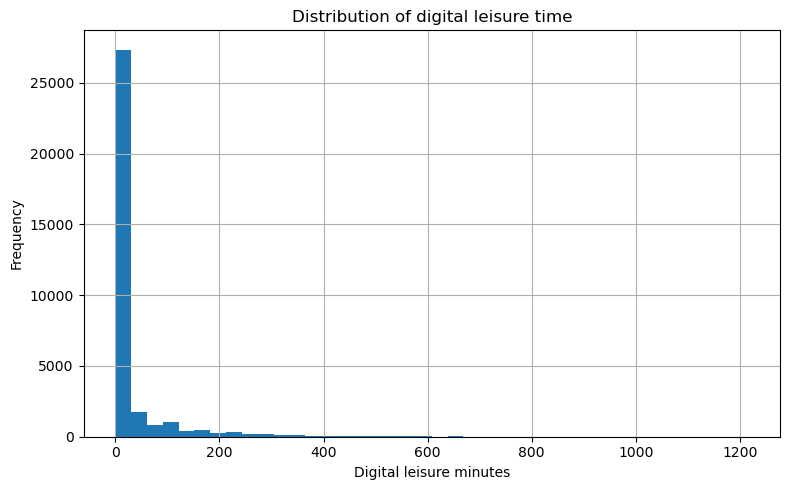

In [57]:
# Histogram for digital leisure
plt.figure(figsize=(8, 5))
df_rq1["DIGITAL_LEISURE"].hist(bins=40)
plt.xlabel("Digital leisure minutes")
plt.ylabel("Frequency")
plt.title("Distribution of digital leisure time")
plt.tight_layout()
plt.savefig("figures/dist_digital_leisure.png", dpi=300, bbox_inches="tight")
plt.show()

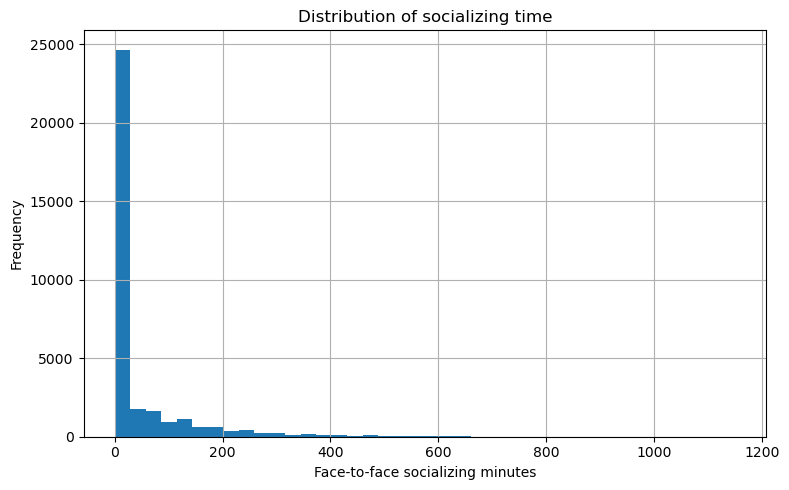

In [58]:
# Histogram for socializing
plt.figure(figsize=(8, 5))
df_rq1["BLS_LEIS_SOCCOM"].hist(bins=40)
plt.xlabel("Face-to-face socializing minutes")
plt.ylabel("Frequency")
plt.title("Distribution of socializing time")
plt.tight_layout()
plt.savefig("figures/dist_socializing.png", dpi=300, bbox_inches="tight")
plt.show()

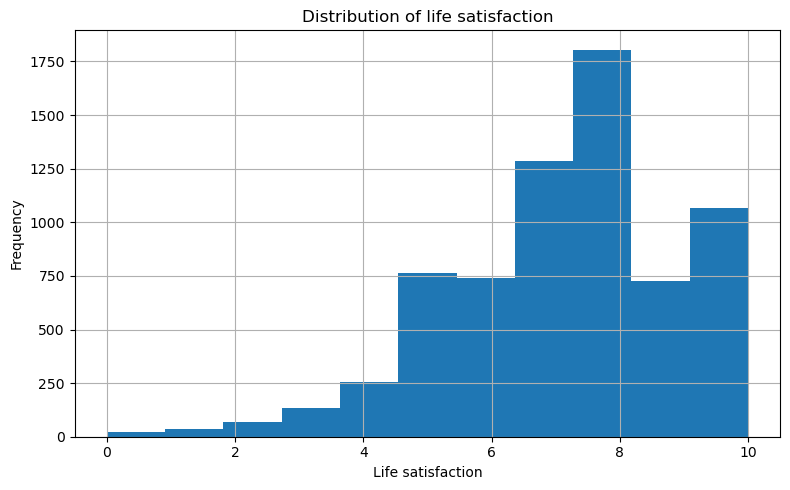

In [59]:
# Histogram for life satisfaction
plt.figure(figsize=(8, 5))
df_rq2["WBLADDER"].hist(bins=11)
plt.xlabel("Life satisfaction")
plt.ylabel("Frequency")
plt.title("Distribution of life satisfaction")
plt.tight_layout()
plt.savefig("figures/dist_life_satisfaction.png", dpi=300, bbox_inches="tight")
plt.show()

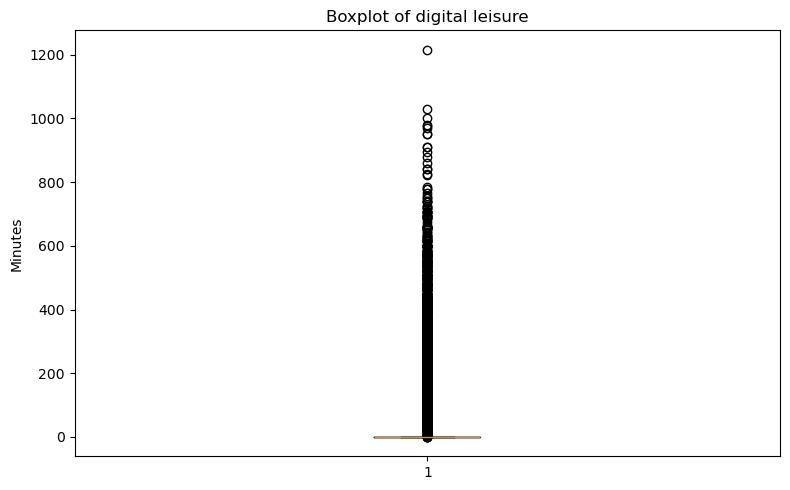

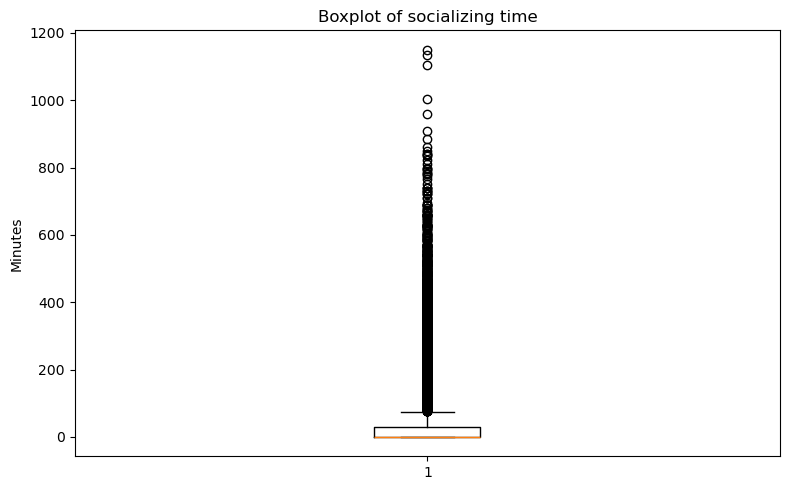

In [60]:
# boxplots
plt.figure(figsize=(8, 5))
plt.boxplot(df_rq1["DIGITAL_LEISURE"])
plt.title("Boxplot of digital leisure")
plt.ylabel("Minutes")
plt.tight_layout()
plt.savefig("figures/box_digital_leisure.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot(df_rq1["BLS_LEIS_SOCCOM"])
plt.title("Boxplot of socializing time")
plt.ylabel("Minutes")
plt.tight_layout()
plt.savefig("figures/box_socializing.png", dpi=300, bbox_inches="tight")
plt.show()

In [61]:
# helper: weighted mean
def weighted_mean(x, w):
    return np.average(x, weights=w)

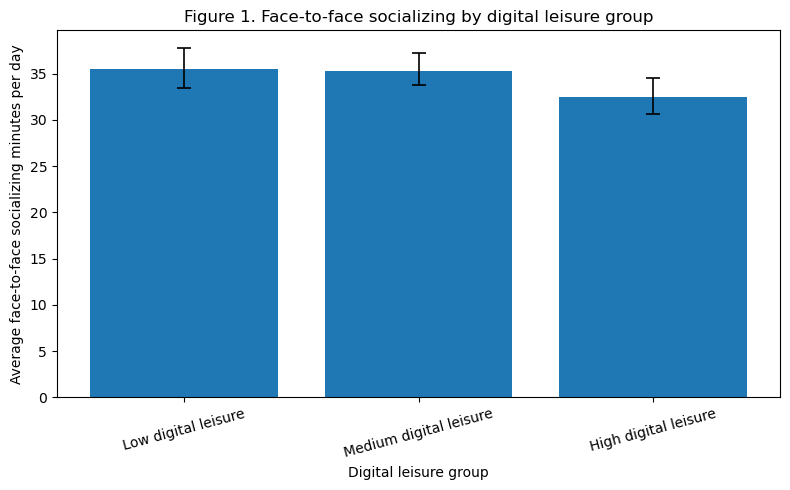

In [62]:
# Figure 1
# face-to-face socializing by digital leisure group (tertiles)
# error bars show 95% bootstrap confidence intervals (500 resamples, weighted)

df_fig1 = df_rq1[["DIGITAL_LEISURE", "BLS_LEIS_SOCCOM", "WT06"]].dropna().copy()
df_fig1 = df_fig1[
    (df_fig1["DIGITAL_LEISURE"] >= 0) &
    (df_fig1["BLS_LEIS_SOCCOM"] >= 0) &
    (df_fig1["WT06"] > 0)
]

df_fig1["digital_leisure_group"] = pd.qcut(
    df_fig1["DIGITAL_LEISURE"].rank(method="first"),
    q=3,
    labels=["Low digital leisure", "Medium digital leisure", "High digital leisure"]
)

# bootstrap 95% CI for each group
rng = np.random.default_rng(42)
n_boot = 500
group_labels = ["Low digital leisure", "Medium digital leisure", "High digital leisure"]

fig1_means = []
fig1_ci_lo = []
fig1_ci_hi = []

for grp in group_labels:
    g = df_fig1[df_fig1["digital_leisure_group"] == grp]
    obs_mean = weighted_mean(g["BLS_LEIS_SOCCOM"], g["WT06"])
    boot_means = [
        weighted_mean(
            g["BLS_LEIS_SOCCOM"].iloc[idx],
            g["WT06"].iloc[idx]
        )
        for idx in (rng.integers(0, len(g), size=(n_boot, len(g))))
    ]
    fig1_means.append(obs_mean)
    fig1_ci_lo.append(obs_mean - np.percentile(boot_means, 2.5))
    fig1_ci_hi.append(np.percentile(boot_means, 97.5) - obs_mean)

plt.figure(figsize=(8, 5))
bars = plt.bar(group_labels, fig1_means,
               yerr=[fig1_ci_lo, fig1_ci_hi],
               capsize=5, error_kw=dict(elinewidth=1.2, capthick=1.2))
plt.xlabel("Digital leisure group")
plt.ylabel("Average face-to-face socializing minutes per day")
plt.title("Figure 1. Face-to-face socializing by digital leisure group")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("figures/figure1_socializing_by_digital_leisure_group.png", dpi=300, bbox_inches="tight")
plt.show()


/var/folders/t4/mzz257_92yl0qgsnfg47g0zr0000gn/T/ipykernel_56257/3447284785.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/var/folders/t4/mzz257_92yl0qgsnfg47g0zr0000gn/T/ipykernel_56257/3447284785.py:53: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


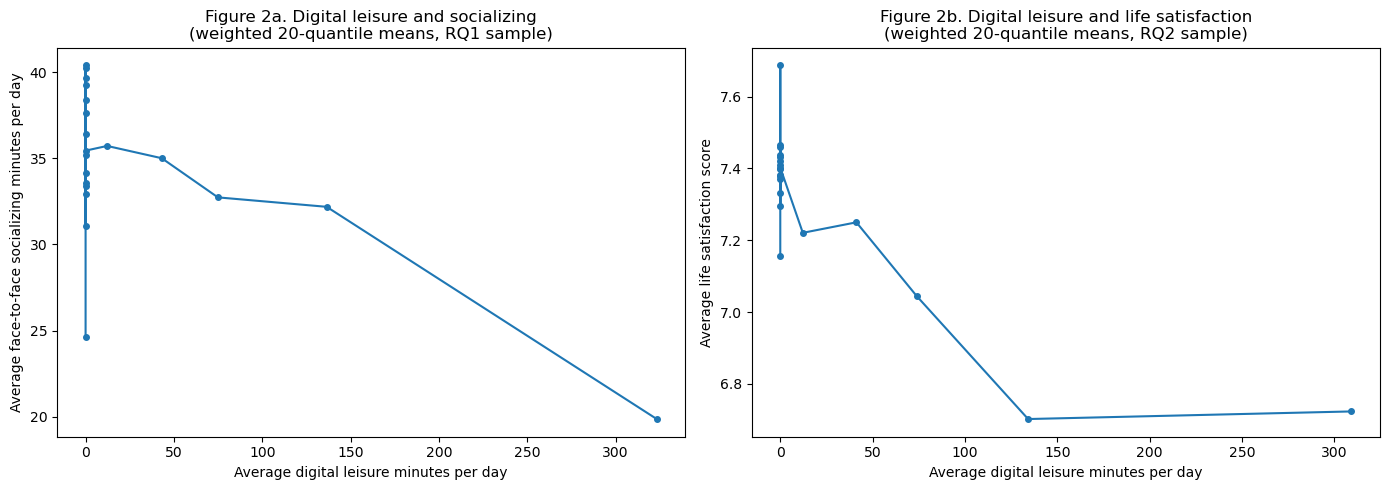

In [63]:
# Figure 2
# continuous relationship between digital leisure and outcomes (20-quantile means)
# uses finer bins than Figure 1 to show whether the trend is linear
# and to reveal any jump between zero and non-zero users

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- left panel: digital leisure vs. socializing (RQ1 sample) ---
df_fig2a = df_rq1[["DIGITAL_LEISURE", "BLS_LEIS_SOCCOM", "WT06"]].dropna().copy()
df_fig2a = df_fig2a[
    (df_fig2a["DIGITAL_LEISURE"] >= 0) &
    (df_fig2a["BLS_LEIS_SOCCOM"] >= 0) &
    (df_fig2a["WT06"] > 0)
]

df_fig2a["dl_quantile"] = pd.qcut(
    df_fig2a["DIGITAL_LEISURE"].rank(method="first"),
    q=20,
    labels=False
)

fig2a_summary = (
    df_fig2a
    .groupby("dl_quantile", observed=True)
    .apply(lambda g: pd.Series({
        "mean_dl": weighted_mean(g["DIGITAL_LEISURE"], g["WT06"]),
        "mean_soccom": weighted_mean(g["BLS_LEIS_SOCCOM"], g["WT06"])
    }))
    .reset_index()
)

axes[0].plot(fig2a_summary["mean_dl"], fig2a_summary["mean_soccom"], marker="o", markersize=4)
axes[0].set_xlabel("Average digital leisure minutes per day")
axes[0].set_ylabel("Average face-to-face socializing minutes per day")
axes[0].set_title("Figure 2a. Digital leisure and socializing\n(weighted 20-quantile means, RQ1 sample)")

# --- right panel: digital leisure vs. life satisfaction (RQ2 sample) ---
df_fig2b = df_rq2[["DIGITAL_LEISURE", "WBLADDER", "WBWT"]].dropna().copy()
df_fig2b = df_fig2b[
    (df_fig2b["DIGITAL_LEISURE"] >= 0) &
    (df_fig2b["WBWT"] > 0)
]

df_fig2b["dl_quantile"] = pd.qcut(
    df_fig2b["DIGITAL_LEISURE"].rank(method="first"),
    q=20,
    labels=False
)

fig2b_summary = (
    df_fig2b
    .groupby("dl_quantile", observed=True)
    .apply(lambda g: pd.Series({
        "mean_dl": weighted_mean(g["DIGITAL_LEISURE"], g["WBWT"]),
        "mean_wbladder": weighted_mean(g["WBLADDER"], g["WBWT"])
    }))
    .reset_index()
)

axes[1].plot(fig2b_summary["mean_dl"], fig2b_summary["mean_wbladder"], marker="o", markersize=4)
axes[1].set_xlabel("Average digital leisure minutes per day")
axes[1].set_ylabel("Average life satisfaction score")
axes[1].set_title("Figure 2b. Digital leisure and life satisfaction\n(weighted 20-quantile means, RQ2 sample)")

plt.tight_layout()
plt.savefig("figures/figure2_continuous_relationship.png", dpi=300, bbox_inches="tight")
plt.show()

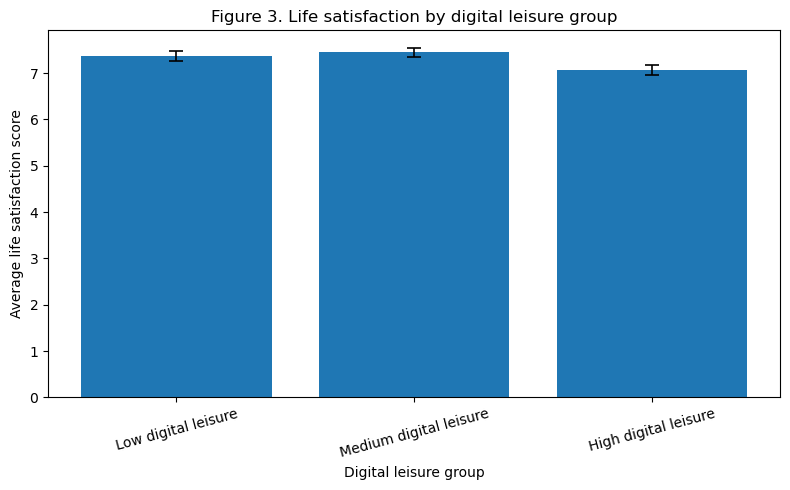

In [64]:
# Figure 3
# life satisfaction by digital leisure group (tertiles)
# error bars show 95% bootstrap confidence intervals (500 resamples, weighted)

df_fig3 = df_rq2[["DIGITAL_LEISURE", "WBLADDER", "WBWT"]].dropna().copy()
df_fig3 = df_fig3[
    (df_fig3["DIGITAL_LEISURE"] >= 0) &
    (df_fig3["WBWT"] > 0)
]

df_fig3["digital_leisure_group"] = pd.qcut(
    df_fig3["DIGITAL_LEISURE"].rank(method="first"),
    q=3,
    labels=["Low digital leisure", "Medium digital leisure", "High digital leisure"]
)

# bootstrap 95% CI for each group
rng3 = np.random.default_rng(42)
n_boot = 500

fig3_means = []
fig3_ci_lo = []
fig3_ci_hi = []

for grp in group_labels:
    g = df_fig3[df_fig3["digital_leisure_group"] == grp]
    obs_mean = weighted_mean(g["WBLADDER"], g["WBWT"])
    boot_means = [
        weighted_mean(
            g["WBLADDER"].iloc[idx],
            g["WBWT"].iloc[idx]
        )
        for idx in (rng3.integers(0, len(g), size=(n_boot, len(g))))
    ]
    fig3_means.append(obs_mean)
    fig3_ci_lo.append(obs_mean - np.percentile(boot_means, 2.5))
    fig3_ci_hi.append(np.percentile(boot_means, 97.5) - obs_mean)

plt.figure(figsize=(8, 5))
plt.bar(group_labels, fig3_means,
        yerr=[fig3_ci_lo, fig3_ci_hi],
        capsize=5, error_kw=dict(elinewidth=1.2, capthick=1.2))
plt.xlabel("Digital leisure group")
plt.ylabel("Average life satisfaction score")
plt.title("Figure 3. Life satisfaction by digital leisure group")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("figures/figure3_life_satisfaction_by_digital_leisure_group.png", dpi=300, bbox_inches="tight")
plt.show()


### 5. Poster Supplement – Data Summary

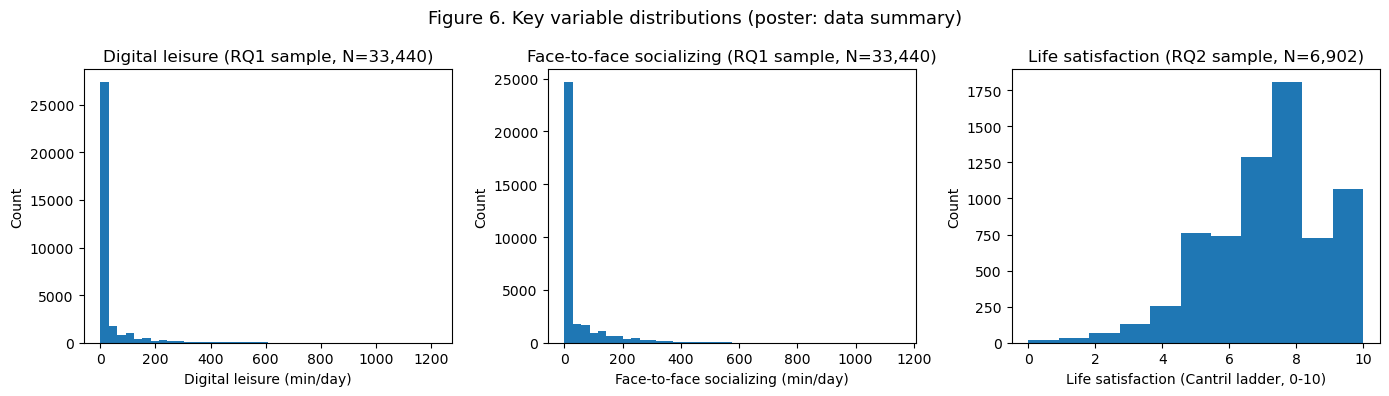

In [65]:
# Figure 6 (Poster: Data Summary)
# Data summary: key variable distributions side by side
# intended for the Data Summary and Methods section of the poster

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# panel 1: distribution of digital leisure (RQ1 sample)
axes[0].hist(df_rq1["DIGITAL_LEISURE"], bins=40, edgecolor="none")
axes[0].set_xlabel("Digital leisure (min/day)")
axes[0].set_ylabel("Count")
axes[0].set_title("Digital leisure (RQ1 sample, N=33,440)")

# panel 2: distribution of face-to-face socializing (RQ1 sample)
axes[1].hist(df_rq1["BLS_LEIS_SOCCOM"], bins=40, edgecolor="none")
axes[1].set_xlabel("Face-to-face socializing (min/day)")
axes[1].set_ylabel("Count")
axes[1].set_title("Face-to-face socializing (RQ1 sample, N=33,440)")

# panel 3: distribution of life satisfaction (RQ2 sample)
axes[2].hist(df_rq2["WBLADDER"].dropna(), bins=11, edgecolor="none")
axes[2].set_xlabel("Life satisfaction (Cantril ladder, 0-10)")
axes[2].set_ylabel("Count")
axes[2].set_title("Life satisfaction (RQ2 sample, N=6,902)")

fig.suptitle("Figure 6. Key variable distributions (poster: data summary)", fontsize=13)
plt.tight_layout()
plt.savefig("figures/figure6_variable_distributions.png", dpi=300, bbox_inches="tight")
plt.show()


## II. Modeling

### 1. RQ1 – Digital Leisure and Face-to-Face Socializing

In [66]:
# RQ1 baseline
m1 = smf.wls(
    "BLS_LEIS_SOCCOM ~ DIGITAL_LEISURE",
    data=df_rq1,
    weights=df_rq1["WT06"]
).fit(cov_type="HC3")

print(m1.summary())

                            WLS Regression Results                            
Dep. Variable:        BLS_LEIS_SOCCOM   R-squared:                       0.002
Model:                            WLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     133.0
Date:                Mon, 18 May 2026   Prob (F-statistic):           1.02e-30
Time:                        19:12:48   Log-Likelihood:            -1.9982e+05
No. Observations:               33440   AIC:                         3.996e+05
Df Residuals:                   33438   BIC:                         3.997e+05
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          35.8718      0.614     

In [67]:
# RQ1 with controls
m2 = smf.wls(
    "BLS_LEIS_SOCCOM ~ DIGITAL_LEISURE + BLS_LEIS_TV + AGE + C(SEX) + C(RACE) + C(MARST) + C(EDUC) + C(EMPSTAT) + C(FAMINCOME) + C(REGION) + C(MONTH) + C(DAY) + C(GENHEALTH) + C(KIDUND18)",
    data=df_rq1,
    weights=df_rq1["WT06"]
).fit(cov_type="HC3")

print(m2.summary())

                            WLS Regression Results                            
Dep. Variable:        BLS_LEIS_SOCCOM   R-squared:                       0.059
Model:                            WLS   Adj. R-squared:                  0.056
Method:                 Least Squares   F-statistic:                     12.08
Date:                Mon, 18 May 2026   Prob (F-statistic):          1.93e-157
Time:                        19:12:49   Log-Likelihood:            -1.3675e+05
No. Observations:               22974   AIC:                         2.737e+05
Df Residuals:                   22888   BIC:                         2.744e+05
Df Model:                          85                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              80.3627    

/opt/anaconda3/envs/agents/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 86, but rank is 85
  warnings.warn('covariance of constraints does not have full '


The baseline model (m1) shows a statistically significant negative association between digital leisure and face-to-face socializing (coef = -0.046, p < 0.001, N = 33,440), though R-squared is only 0.002, which is expected given the high day-to-day variability in time use. After adding controls (m2), the coefficient on digital leisure becomes more negative (-0.075, p < 0.001, N = 22,974), suggesting that the negative association remains after adding demographic and situational controls. TV time is also negatively associated with socializing (coef = -0.080, p < 0.001). Age is not statistically significant in the controlled model (coef = -0.067, p = 0.211); the 95% confidence interval [-0.173, 0.038] crosses zero, so this coefficient should not be interpreted as clearly different from zero in this model.

### 2. RQ1 – Result Visualization

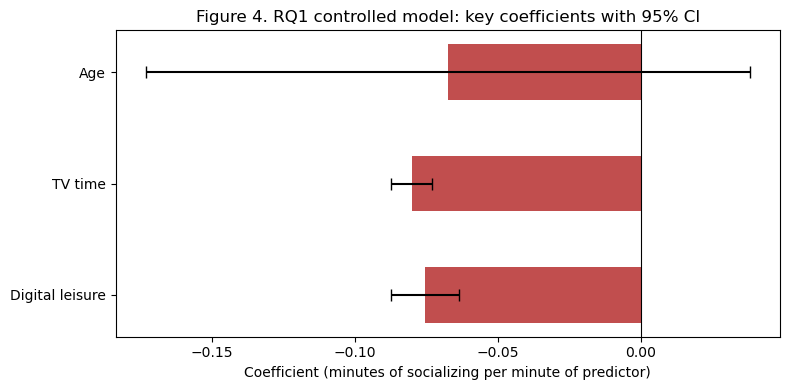

RQ1 key coefficients (controlled model):
DIGITAL_LEISURE   -0.0754
BLS_LEIS_TV       -0.0801
AGE               -0.0674
dtype: float64

95% CI:
                      0       1
DIGITAL_LEISURE -0.0872 -0.0636
BLS_LEIS_TV     -0.0873 -0.0728
AGE             -0.1730  0.0382

N (after listwise deletion): 22974


In [68]:
# Figure 4
# coefficient plot for RQ1 controlled model (m2)
# shows the three continuous predictors with 95% CI

key_vars_rq1 = ["DIGITAL_LEISURE", "BLS_LEIS_TV", "AGE"]
labels_rq1  = ["Digital leisure", "TV time", "Age"]

coef_rq1 = m2.params[key_vars_rq1]
ci_rq1   = m2.conf_int().loc[key_vars_rq1]

plt.figure(figsize=(8, 4))
y_pos = range(len(key_vars_rq1))
plt.barh(
    list(y_pos), coef_rq1.values,
    xerr=[(coef_rq1 - ci_rq1[0]).values, (ci_rq1[1] - coef_rq1).values],
    color=["firebrick" if c < 0 else "steelblue" for c in coef_rq1.values],
    alpha=0.8, height=0.5, capsize=4
)
plt.axvline(0, color="black", linewidth=0.8)
plt.yticks(list(y_pos), labels_rq1)
plt.xlabel("Coefficient (minutes of socializing per minute of predictor)")
plt.title("Figure 4. RQ1 controlled model: key coefficients with 95% CI")
plt.tight_layout()
plt.savefig("figures/figure4_rq1_coefplot.png", dpi=300, bbox_inches="tight")
plt.show()

# print key estimates
print("RQ1 key coefficients (controlled model):")
print(m2.params[key_vars_rq1].round(4))
print("\n95% CI:")
print(m2.conf_int().loc[key_vars_rq1].round(4))
print(f"\nN (after listwise deletion): {int(m2.nobs)}")

### 3. RQ2 – Digital Leisure and Life Satisfaction

In [69]:
# RQ2 baseline
m3 = smf.wls(
    "WBLADDER ~ DIGITAL_LEISURE",
    data=df_rq2,
    weights=df_rq2["WBWT"]
).fit(cov_type="HC3")

print(m3.summary())

                            WLS Regression Results                            
Dep. Variable:               WBLADDER   R-squared:                       0.013
Model:                            WLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     51.79
Date:                Mon, 18 May 2026   Prob (F-statistic):           6.83e-13
Time:                        19:12:51   Log-Likelihood:                -15259.
No. Observations:                6902   AIC:                         3.052e+04
Df Residuals:                    6900   BIC:                         3.054e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           7.3694      0.032    2

In [70]:
# RQ2 with controls
m4 = smf.wls(
    "WBLADDER ~ DIGITAL_LEISURE + AGE + C(SEX) + C(RACE) + C(MARST) + C(EDUC) + C(EMPSTAT) + C(FAMINCOME) + C(REGION) + C(MONTH) + C(DAY) + C(GENHEALTH) + C(KIDUND18)",
    data=df_rq2,
    weights=df_rq2["WBWT"]
).fit(cov_type="HC3")

print(m4.summary())

                            WLS Regression Results                            
Dep. Variable:               WBLADDER   R-squared:                       0.188
Model:                            WLS   Adj. R-squared:                  0.179
Method:                 Least Squares   F-statistic:                     1391.
Date:                Mon, 18 May 2026   Prob (F-statistic):               0.00
Time:                        19:12:51   Log-Likelihood:                -14584.
No. Observations:                6902   AIC:                         2.932e+04
Df Residuals:                    6824   BIC:                         2.986e+04
Df Model:                          77                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               7.0971    

/opt/anaconda3/envs/agents/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 80, but rank is 78
  warnings.warn('covariance of constraints does not have full '


The baseline model (m3) shows a statistically significant negative association between digital leisure and life satisfaction (coef = -0.003, p < 0.001, N = 6,902), with R-squared of 0.013. After adding controls (m4), the coefficient attenuates somewhat (-0.002, p < 0.001) but remains significant, and R-squared increases substantially to 0.188 after adding demographic and health-related controls. Several controls, including general health and marital status, appear to be important predictors in the controlled model. Unlike in RQ1, age is positively and significantly associated with life satisfaction after controlling for other variables (coef = 0.014, p < 0.001).

### 4. RQ2 – Result Visualization

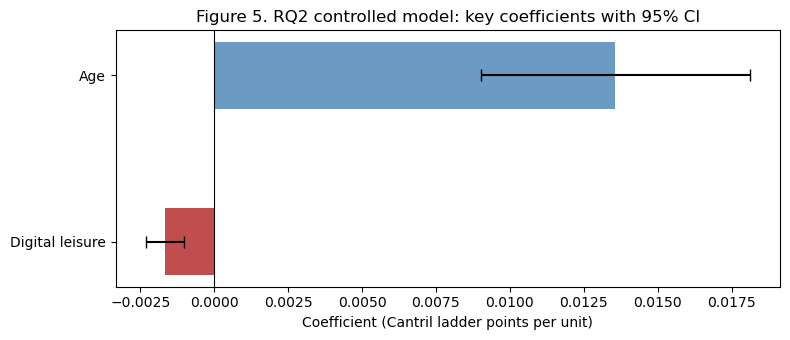

RQ2 key coefficients (controlled model):
DIGITAL_LEISURE   -0.0017
AGE                0.0136
dtype: float64

95% CI:
                      0       1
DIGITAL_LEISURE -0.0023 -0.0010
AGE              0.0090  0.0181

N (after listwise deletion): 6902


In [71]:
# Figure 5
# coefficient plot for RQ2 controlled model (m4)

key_vars_rq2 = ["DIGITAL_LEISURE", "AGE"]
labels_rq2  = ["Digital leisure", "Age"]

coef_rq2 = m4.params[key_vars_rq2]
ci_rq2   = m4.conf_int().loc[key_vars_rq2]

plt.figure(figsize=(8, 3.5))
y_pos = range(len(key_vars_rq2))
plt.barh(
    list(y_pos), coef_rq2.values,
    xerr=[(coef_rq2 - ci_rq2[0]).values, (ci_rq2[1] - coef_rq2).values],
    color=["firebrick" if c < 0 else "steelblue" for c in coef_rq2.values],
    alpha=0.8, height=0.4, capsize=4
)
plt.axvline(0, color="black", linewidth=0.8)
plt.yticks(list(y_pos), labels_rq2)
plt.xlabel("Coefficient (Cantril ladder points per unit)")
plt.title("Figure 5. RQ2 controlled model: key coefficients with 95% CI")
plt.tight_layout()
plt.savefig("figures/figure5_rq2_coefplot.png", dpi=300, bbox_inches="tight")
plt.show()

# print key estimates
print("RQ2 key coefficients (controlled model):")
print(m4.params[key_vars_rq2].round(4))
print("\n95% CI:")
print(m4.conf_int().loc[key_vars_rq2].round(4))
print(f"\nN (after listwise deletion): {int(m4.nobs)}")

## III. Summary

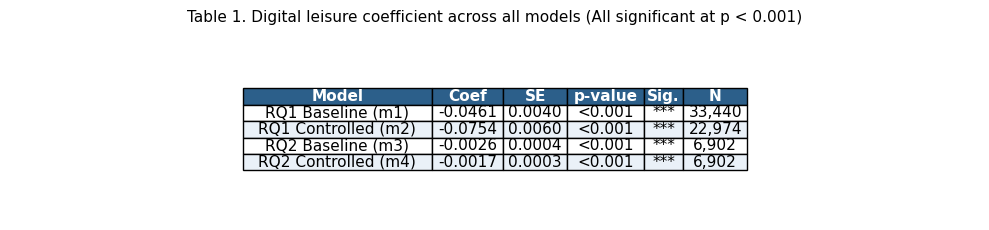

In [72]:
# Table 1
# regression summary: DIGITAL_LEISURE coefficient across all four models
# rendered as a matplotlib figure so it can be saved and used in the poster

rows = []
for label, model in [
    ("RQ1 Baseline (m1)", m1),
    ("RQ1 Controlled (m2)", m2),
    ("RQ2 Baseline (m3)", m3),
    ("RQ2 Controlled (m4)", m4)
]:
    coef  = model.params["DIGITAL_LEISURE"]
    se    = model.bse["DIGITAL_LEISURE"]
    pval  = model.pvalues["DIGITAL_LEISURE"]
    n     = int(model.nobs)
    stars = "***" if pval < 0.001 else ("**" if pval < 0.01 else ("*" if pval < 0.05 else ""))
    pval_text = "<0.001" if pval < 0.001 else f"{pval:.4f}"
    rows.append([label, f"{coef:.4f}", f"{se:.4f}", pval_text, stars, f"{n:,}"])

col_headers = ["Model", "Coef", "SE", "p-value", "Sig.", "N"]

# render as a matplotlib table figure
fig, ax = plt.subplots(figsize=(10, 2.4))
ax.axis("off")

tbl = ax.table(
    cellText=rows,
    colLabels=col_headers,
    cellLoc="center",
    loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.auto_set_column_width(col=list(range(len(col_headers))))

# style header row
for col_idx in range(len(col_headers)):
    tbl[(0, col_idx)].set_facecolor("#2c5f8a")
    tbl[(0, col_idx)].set_text_props(color="white", fontweight="bold")

# alternate row shading
for row_idx in range(1, len(rows) + 1):
    bg = "#eaf1f8" if row_idx % 2 == 0 else "white"
    for col_idx in range(len(col_headers)):
        tbl[(row_idx, col_idx)].set_facecolor(bg)

plt.title("Table 1. Digital leisure coefficient across all models (All significant at p < 0.001)",
          fontsize=11, pad=12)
plt.tight_layout()
plt.savefig("figures/table1_regression_summary.png", dpi=300, bbox_inches="tight")
plt.show()

# also export as csv for reference
import pandas as pd
summary_df = pd.DataFrame(rows, columns=col_headers)
summary_df.to_csv("figures/table1_regression_summary.csv", index=False)


Both research questions show a statistically significant negative association between digital leisure and the outcome variable, and both survive the addition of demographic controls. For RQ1, the digital leisure coefficient becomes slightly more negative after adding controls (-0.046 to -0.075), which suggests that the displacement pattern remains after controlling for measured demographic and situational differences between heavy and light digital leisure users. For RQ2, the coefficient attenuates after adding controls (-0.003 to -0.002) but remains significant, consistent with a small but statistically significant negative association between digital leisure and life satisfaction in the 2021 sample.